# 4. Advanced - conditions and grouping models

> [!WARNING]
> This tutorial and the associated functions are still under construction, only use these functions for development puprose 


For this tutorial we will simulate data for two participants, one with noise and one without. We make the simulation deterministic by providing the exact times at which we want the events to occur for two trials.
Importantly we will use the same source names and parameters for both participants, but we will swap the first two sources between the two participants. This will allow us to test the grouping model's ability to handle different event configuration across conditions or participants.

## Splitting conditions

When estimating a model across all conditions, we can also split the data by condition. This is useful to see how the model estimates differ across conditions, such as speed vs accuracy instructions in this case.

### Same model

A first thing can be to just split the probabilities we estimated on both conditions simultaneously and plot them.

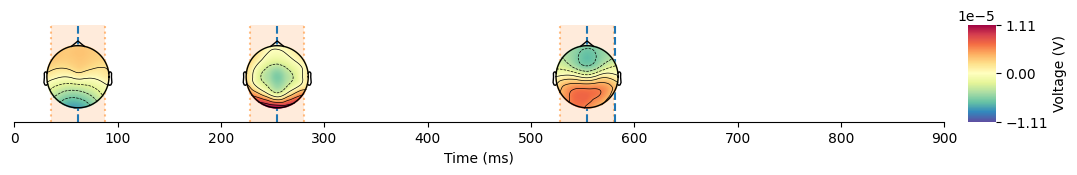

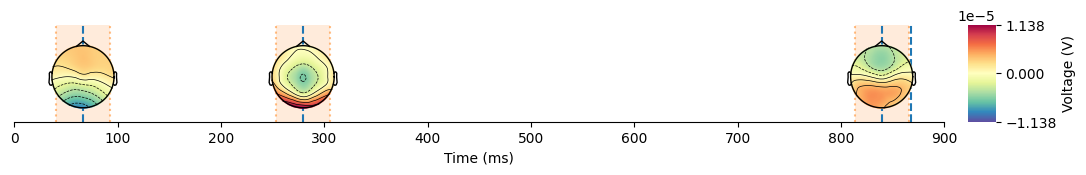

In [ ]:
speed_estimates = hmp.utils.select_coord(estimates_cumulative, 'SP', variable='cue')
accuracy_estimates =  hmp.utils.select_coord(estimates_cumulative, 'AC', variable='cue')

hmp.visu.plot_topo_timecourse(epoch_data, speed_estimates, info, max_time=900)
hmp.visu.plot_topo_timecourse(epoch_data, accuracy_estimates, info, max_time=900)

But in this case the HMP parameters are all shared across conditions so we might want to estimate the model separately for each condition if there is a reason to expect a difference. This is done by selecting the condition of interest and then estimating the model on the selected data.

### Independent models

In [ ]:
hmp_data_speed = hmp_data.select_coord(value='SP', variable='cue')
hmp_data_accuracy = hmp_data.select_coord(value='AC', variable='cue')

  0%|          | 0/22 [00:00<?, ?it/s]

1 events found around times [84]
2 events found around times [76, 276]
3 events found around times [80, 276, 544]


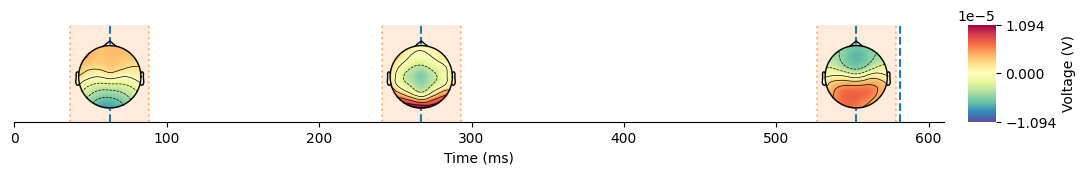

In [ ]:
model_speed = hmp.models.CumulativeMethod()
model_speed.fit(hmp_data_speed)
ll_cumulative_speed, estimates_speed = model_speed.transform(hmp_data_speed)
hmp.visu.plot_topo_timecourse(epoch_data, estimates_speed, info)

  0%|          | 0/34 [00:00<?, ?it/s]

1 events found around times [76]
2 events found around times [80, 288]
3 events found around times [84, 280, 536]
4 events found around times [80, 272, 512, 832]


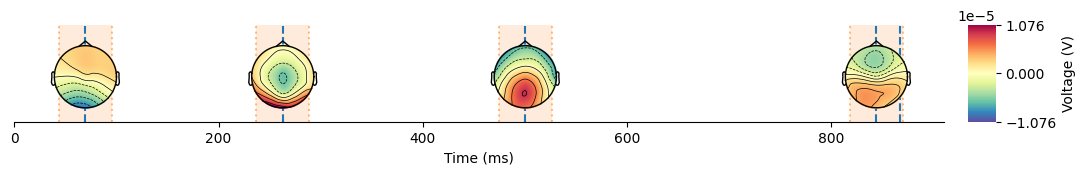

In [ ]:
model_accuracy = hmp.models.CumulativeMethod()
model_accuracy.fit(hmp_data_accuracy)
ll_cumulative_accuracy, estimates_accuracy = model_accuracy.transform(hmp_data_accuracy)
hmp.visu.plot_topo_timecourse(epoch_data, estimates_accuracy, info)

In this case, the models are completely independent and the cumulative method finds an additional event in the accuracy condition.